[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/dkaratzas/DL2022-23/blob/main/Problems%204%20-%20MLP%20for%20Images/P4_MLP_for_Images.ipynb)

# MLP for image classification

In this notebook we are going to learn how to use a Multi-Layer Perceptron (MLP) (Fully-Connected, Feed-Forward Network) for classifying images.

An MLP like the ones you used in the notebook of last week can be used with any kind of input data if we can represent it as a vector of real numbers. The shape of the input vector determines the size of the first layer in the model.

In the case of images (2D arrays of pixel values) we can get fixed-length vectors by: (1) using always images of the same size, and (2) flatenning the images into a 1D array. The flatten operation collapses an array into one dimension. For example, if we have a grayscale image of $28\times28$ pixels, its flattened version is a 1d array of $784$ pixel values. Now we can fed these $784$ values into a MLP for classifiying the image.

### Import the necessary libraries

In [1]:
import torch #should be installed by default in any colab notebook
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

### Use GPU if available

In [2]:
# If this cell fails you need to change the runtime of your colab notebook to GPU
# Go to Runtime -> Change Runtime Type and select GPU
assert torch.cuda.is_available(), "GPU is not enabled"

# use gpu if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## The Fashion-MNIST dataset

[**Fashion-MNIST**](https://pytorch.org/vision/0.8/datasets.html#fashion-mnist) is a dataset consisting of a training set of $60,000$ examples and a test set of $10,000$ examples. Each example is a $28\times28$ grayscale image, associated with a label from $10$ classes. It was proposed as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms. It shares the same image size and structure of training and testing splits.

Each training and test example is assigned to one of the following labels: 0 T-shirt/top, 1 Trouser, 2 Pullover, 3 Dress, 4 Coat, 5 Sandal, 6 Shirt, 7 Sneaker, 8 Bag, 9 Ankle boot.

The Fashion-MNIST dataset is available in [torchvision](https://pytorch.org/vision/stable/index.html) and can be loaded with the following code:

In [3]:
train_set = datasets.FashionMNIST("data", train=True, download=True, transform=transforms.Compose([transforms.ToTensor()]))
val_set = datasets.FashionMNIST("data", train=False, download=True, transform=transforms.Compose([transforms.ToTensor()]))

print(train_set.data.size(), val_set.data.size())
print(train_set.targets.size(), val_set.targets.size())

100%|██████████| 26421880/26421880 [00:01<00:00, 15431160.86it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 278506.81it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 5001402.22it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 22145925.12it/s]


Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])
torch.Size([60000]) torch.Size([10000])


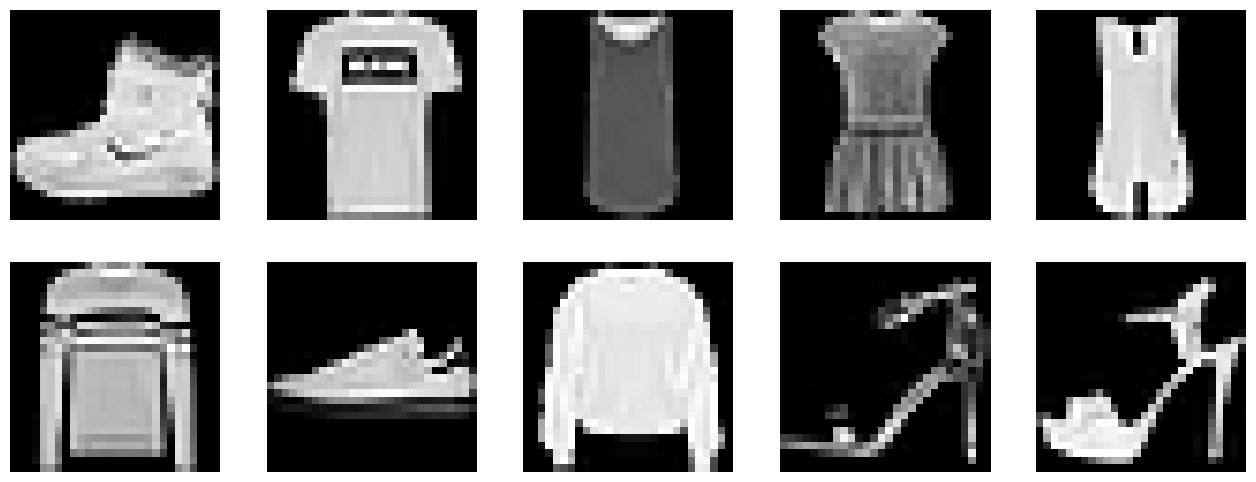

In [4]:
# show some images
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image = train_set.data[i,...]
    plt.imshow(image.squeeze().numpy(), cmap="gray")
    plt.axis('off');

<font color="blue">**Exercise 1**: When we loaded the Fashion-MNIST dataset we used the method `transforms.Compose`. Take a look at the documentation of [torchvision.transforms](https://pytorch.org/vision/0.8/transforms.html?highlight=transforms). Is there another transform that we can add to make our classification problem easier?</font>

---

We can normalize the data, or resize the pictures in the case they are not of the same. Here, all the images have the sae dimensions, so the second transform seems not to be really interesting.


---

# Dataloaders

Now we introduce a **critical piece in any deep learning training process**: the dataloader. In Pytorch we can create a dataloader for a given dataset as follows:


In [5]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=False, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=1, shuffle=False, num_workers=0)

<font color="blue">**Exercise 2**: Take a look at the documentation of [torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html?highlight=dataloader#torch.utils.data.DataLoader) and answer the following questions:</font>

<font color="blue">- What are the benefits of a dataloader?</font>

<font color="blue">- How can we make the dataloaders defined above better?</font>

---

A dataloader makes life easier : it manages the dataset, provides function to sample from it (into mini-batches), or to iterate through it.

To improve those two datset, we could increase the batch sizes, and maybe suffle the data as well.

---

<font color="blue">**Exercise 3**: Now re-define the datasets and the dataloaders, and introduce normalisation (use the average of image means and stds of the training set for this), turn shuffling on, and use a batch size of 32.</font>

In [6]:
# Redefinition of the datasets
## First, we determine the mean and the std
m_train = 0
std_train = 0
for item, label in train_set:
  m_train += item.mean()
  std_train += item.std()

m_train = m_train / len(train_set)
std_train = std_train / len(train_set)

print("mean : ", m_train)
print("std :", std_train)

mean :  tensor(0.2860)
std : tensor(0.3205)


In [7]:
# We add the normalization
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.2860,), (0.3205,))])

# We re-define our datasets
train_set = datasets.FashionMNIST("data", train=True, download=True, transform=transform)
val_set = datasets.FashionMNIST("data", train=False, download=True, transform=transform)
# We re-define our dataloaders
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=True, num_workers=0)

<font color="blue">**Exercise 4**: Define the class for an MLP with two hidden layers using ReLU activations. The sizes of the input, output and hidden layers should be given during initialisation (using the `__init__()` class constructor parameters).</font>

In [8]:
# We define a network with 2 hidden layer, having relu activation functions
class FCModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FCModel, self).__init__()
        self.input_size = input_size
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size,output_size)
        )

    def forward(self, x):
        x = x.view(-1, self.input_size)
        return self.network(x)


## Parameter Initialization

In PyTorch the default parameter initialization depends on the layer type. For example, for the Linear layer the default initialization is defined [here](https://github.com/pytorch/pytorch/blob/master/torch/nn/modules/linear.py#L87). Take a look and see if you recognize the initialization method.

You can find more initialization methods in the [`torch.nn.init`](https://pytorch.org/docs/stable/nn.init.html?highlight=init) module.

If necessary, you can change the default initialization of a layer as follows:

In [9]:
def initialize_parameters(model):
    for name, w in model.named_parameters():
        if "weight" in name:
            nn.init.ones_(w)

        if "bias" in name:
            nn.init.zeros_(w)

## Create the model and initialize its parameters

In [10]:
learning_rate = 1e-3
lambda_l2 = 1e-5
torch.manual_seed(0) # seed for reproductibility

input_size  = 28*28   # images are 28x28 pixels
output_size = 10      # there are 10 classes

model = FCModel(input_size, 128, output_size)

# utility function to count number of parameters in a model
def get_n_params(model):
    np=0
    for p in list(model.parameters()):
        np += p.numel()
    return np

print(f"Number of parameters {get_n_params(model)}:")

# move model to gpu if available
model.to(device)

# nn package also has different loss functions.
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss() # https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss

# we use the optim package to apply
# stochastic gradient descent for our parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=lambda_l2) # built-in L2

# WARNING! What are we doing here? We are initializing the parameters at the same value...
initialize_parameters(model)

Number of parameters 118282:


## Define the train and validation methods

The following code should be easy to follow, but please note the following:

Here we use the function `torch.no_grad()` when we want to indicate to PyTorch that we do not want to calculate gradients. This saves a lot of computation and time, and we use it for example when we want to validate our model, when only forward calculations are needed. There are two ways to apply this function, and you can read about it here:
https://pytorch.org/docs/stable/generated/torch.no_grad.html

The way we use below is called a "decorator" function. It is a special super-power of python, and you can read more about it here:
https://realpython.com/primer-on-python-decorators/

Do not confuse `torch.no_grad()` with `model.eval()` and `model.train()`. The purpose of these two latter functions is to setup our model in different modes. This is very useful if you use layers that work in a different way during training and during evaluation, for example Dropout or Batch Normalisation. The model therefore needs to know how you are using it at any given time.

In [11]:
@torch.no_grad()  # prevent this function from computing gradients see https://pytorch.org/docs/stable/generated/torch.no_grad.html
def validate(criterion, model, loader):

    val_loss = 0
    correct = 0

    model.eval()

    for data, target in loader:

        data, target = data.to(device), target.to(device)

        data = data.view(-1, 28*28)
        output = model(data)
        loss = criterion(output, target)
        val_loss += loss.item()
        pred = output.data.max(1, keepdim=True)[1] # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item()

    val_loss /= len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(loader.dataset),
        accuracy))


    return val_loss


def train(epoch, criterion, model, optimizer, loader):

    total_loss = 0.0

    model.train()

    for batch_idx, (data, target) in enumerate(loader):

        optimizer.zero_grad()

        data, target = data.to(device), target.to(device)

        data = data.view(-1, 28*28)

        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        # print loss every N iterations
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(loader.dataset),
                100. * batch_idx / len(loader), loss.item()))


        total_loss += loss.item()  #.item() is very important here? Why?

    return total_loss / len(loader.dataset)

### The training loop

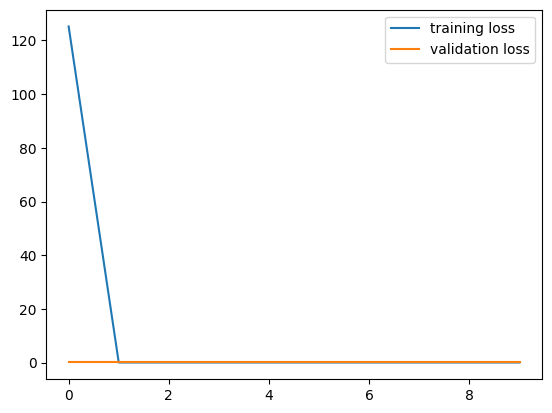

In [12]:
losses = {"train": [], "val": []}
for epoch in range(10):

    train_loss = train(epoch, criterion, model, optimizer, train_loader)
    val_loss = validate(criterion, model, val_loader)
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

    display.clear_output(wait=True)

    plt.plot(losses["train"], label="training loss")
    plt.plot(losses["val"], label="validation loss")

    plt.legend()
    plt.pause(0.000001)
    plt.show()

This training semms not to be efficient since the training loss is decreasing hard one time, and then is quite stabilized. Maybe the reason of this is linked to the bad initialization of the parameters.

# Visualising Results

It may also be useful to visualize some qualitative examples of classification

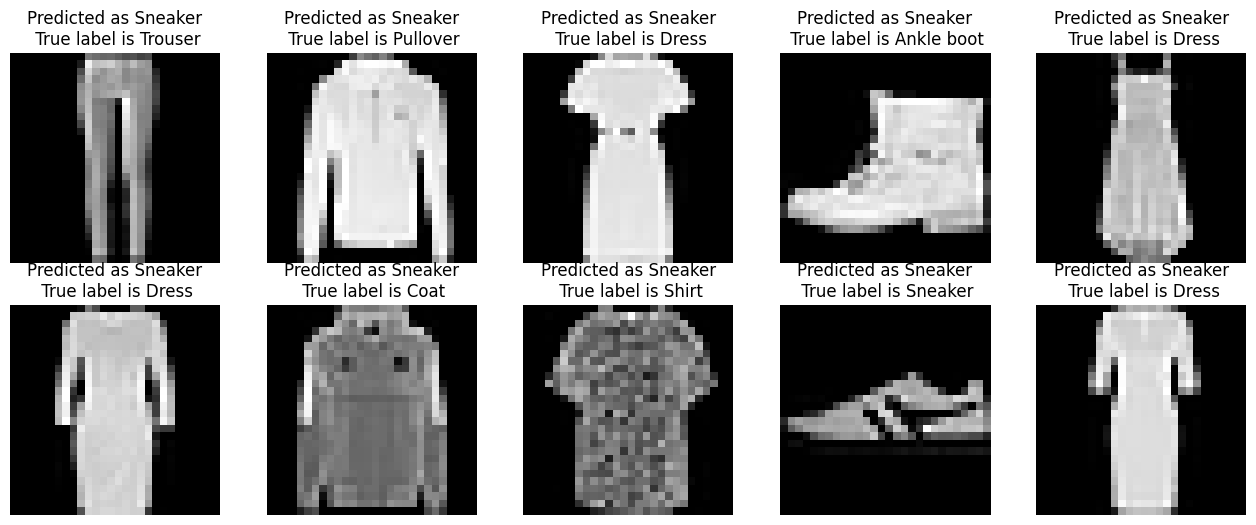

In [13]:
with torch.no_grad():

    data, target = next(iter(val_loader))
    data, target = data.to(device), target.to(device)

    data = data.view(-1, 28*28)
    output = model(data)
    predictions = np.argmax(output.cpu().numpy(), axis=1).tolist()
    true = target.cpu().numpy().tolist()

    plt.figure(figsize=(16, 6))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        image = data[i,...].cpu().numpy().reshape((28,28))
        plt.imshow(image, cmap="gray")
        plt.axis('off')
        plt.title('Predicted as {}\n True label is {}'.format(val_set.classes[predictions[i]], val_set.classes[true[i]], ))

As we could have imagined, the classifications are not well accurate : most of those 10 objects are not well classified.

# Homework

<font color="blue">**Exercise 5**: Change the initialization of the model parameters (this will help a great deal) and train your model on the Fashion-MNIST dataset.</font>

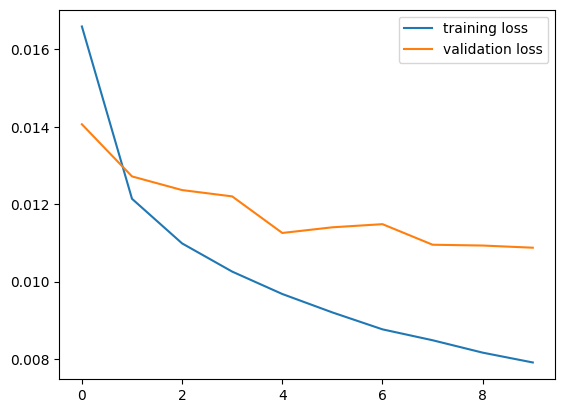

In [14]:
# We change the initialization of the parameters
def initialize_parameters(model):
    for name, w in model.named_parameters():
        if "weight" in name:
            nn.init.kaiming_uniform_(w, nonlinearity='relu')

        if "bias" in name:
            nn.init.zeros_(w)

# We consider the change
initialize_parameters(model)

# Training loop
losses = {"train": [], "val": []}
for epoch in range(10):

    train_loss = train(epoch, criterion, model, optimizer, train_loader)
    val_loss = validate(criterion, model, val_loader)
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

    display.clear_output(wait=True)

    plt.plot(losses["train"], label="training loss")
    plt.plot(losses["val"], label="validation loss")

    plt.legend()
    plt.pause(0.000001)
    plt.show()

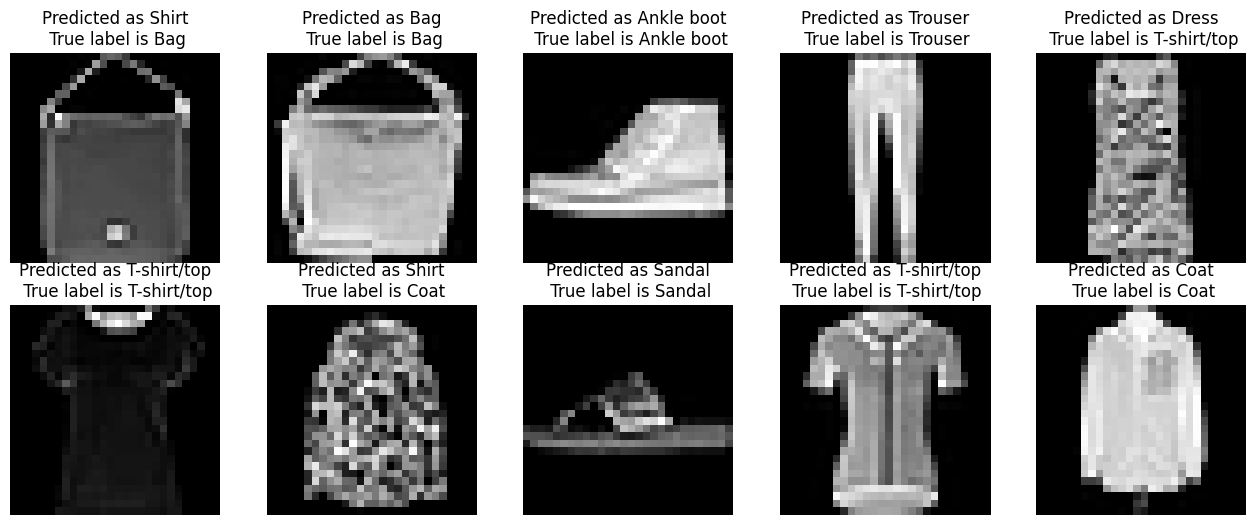

In [15]:
# evaluate the trained model on the validation set
with torch.no_grad():

    data, target = next(iter(val_loader))
    data, target = data.to(device), target.to(device)

    data = data.view(-1, 28*28)
    output = model(data)
    predictions = np.argmax(output.cpu().numpy(), axis=1).tolist()
    true = target.cpu().numpy().tolist()

    plt.figure(figsize=(16, 6))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        image = data[i,...].cpu().numpy().reshape((28,28))
        plt.imshow(image, cmap="gray")
        plt.axis('off')
        plt.title('Predicted as {}\n True label is {}'.format(val_set.classes[predictions[i]], val_set.classes[true[i]], ))

Here we can see that simply by changing the initilization of our model, we get better results. Almost all the test above are well executed, putting apart the coat.

<font color="blue">**Exercise 6**: Try to improve the Accuracy of your model on the validation set by adding more layers and/or more hidden units in you model. For example you can use a MLP with 2 hidden layers with 512 and 256 units respectively. You can also consider changing the batch size and learning rate if needed.</font>

In [16]:
# We define a network with 2 hidden layer, having relu activation functions and 512/256 units respectively
class FCModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FCModel, self).__init__()
        self.input_size = input_size
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size[0]),
            nn.ReLU(),
            nn.Linear(hidden_size[0],hidden_size[1]),
            nn.ReLU(),
            nn.Linear(hidden_size[1],output_size)
        )

    def forward(self, x):
        x = x.view(-1, self.input_size)
        return self.network(x)

# New model
learning_rate = 1e-3
lambda_l2 = 1e-5
torch.manual_seed(0) # seed for reproductibility

input_size  = 28*28   # images are 28x28 pixels
output_size = 10      # there are 10 classes

model = FCModel(input_size, [512,256], output_size)

# utility function to count number of parameters in a model
def get_n_params(model):
    np=0
    for p in list(model.parameters()):
        np += p.numel()
    return np

print(f"Number of parameters {get_n_params(model)}:")

# move model to gpu if available
model.to(device)

# nn package also has different loss functions.
# we use cross entropy loss for our classification task
criterion = torch.nn.CrossEntropyLoss() # https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss

# we use the optim package to apply
# stochastic gradient descent for our parameter updates
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=lambda_l2) # built-in L2

# WARNING! What are we doing here? We are initializing the parameters at the same value...
initialize_parameters(model)

Number of parameters 535818:


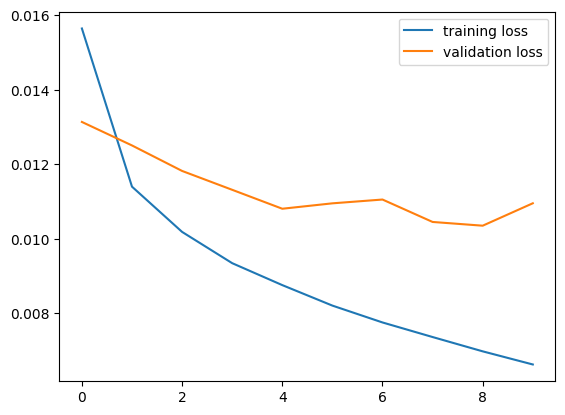

In [17]:
# Training loop
losses = {"train": [], "val": []}
for epoch in range(10):

    train_loss = train(epoch, criterion, model, optimizer, train_loader)
    val_loss = validate(criterion, model, val_loader)
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

    display.clear_output(wait=True)

    plt.plot(losses["train"], label="training loss")
    plt.plot(losses["val"], label="validation loss")

    plt.legend()
    plt.pause(0.000001)
    plt.show()

Here, we can see that the use of a slighly more complex neural network can improve a bit the result since the loss is a bit smaller than before with this new model.

<font color="blue">**Exercise 7**: Try at least two different [optimizers](https://pytorch.org/docs/stable/optim.html#algorithms) (e.g. SGD with momentum, RMSProp, Adam, etc.) and plot **in a single matplotlib figure** the loss curves for training the model with them. We want them in a single figure to be able to easily compare the three learning curves.</font>

In [24]:
# RMSProp
modelRMSProp = FCModel(input_size, [512,256], output_size)
modelRMSProp.to(device)
initialize_parameters(modelRMSProp)
optimizer1 = torch.optim.RMSprop(modelRMSProp.parameters(), lr=learning_rate, alpha=0.99, eps=1e-08, weight_decay=lambda_l2, momentum=0)

# Training loop
losses_RMS = {"train": [], "val": []}
for epoch in range(10):

    train_loss = train(epoch, criterion, modelRMSProp, optimizer1, train_loader)
    val_loss = validate(criterion, modelRMSProp, val_loader)
    losses_RMS["train"].append(train_loss)
    losses_RMS["val"].append(val_loss)

Train Epoch: 0 [0/60000 (0%)]	Loss: 2.304334
Train Epoch: 0 [3200/60000 (5%)]	Loss: 0.668117
Train Epoch: 0 [6400/60000 (11%)]	Loss: 0.491961
Train Epoch: 0 [9600/60000 (16%)]	Loss: 0.290009
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.352097
Train Epoch: 0 [16000/60000 (27%)]	Loss: 0.456170
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.492484
Train Epoch: 0 [22400/60000 (37%)]	Loss: 0.291303
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.492329
Train Epoch: 0 [28800/60000 (48%)]	Loss: 0.209223
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.573265
Train Epoch: 0 [35200/60000 (59%)]	Loss: 0.718292
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.907761
Train Epoch: 0 [41600/60000 (69%)]	Loss: 0.741324
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.346700
Train Epoch: 0 [48000/60000 (80%)]	Loss: 0.197374
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.216316
Train Epoch: 0 [54400/60000 (91%)]	Loss: 0.628016
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.301888

Test set: Average loss: 0.0129, Accuracy: 8501/10000 (85%)

In [25]:
# Adam
modelAdam = FCModel(input_size, [512,256], output_size)
modelAdam.to(device)
initialize_parameters(modelAdam)
optimizer2 = torch.optim.Adam(modelAdam.parameters(), lr=learning_rate, betas=(0.9, 0.999), eps=1e-08, weight_decay=lambda_l2)

# Training loop
losses_Adam = {"train": [], "val": []}
for epoch in range(10):

    train_loss = train(epoch, criterion, modelAdam, optimizer2, train_loader)
    val_loss = validate(criterion, modelAdam, val_loader)
    losses_Adam["train"].append(train_loss)
    losses_Adam["val"].append(val_loss)

Train Epoch: 0 [0/60000 (0%)]	Loss: 3.181646
Train Epoch: 0 [3200/60000 (5%)]	Loss: 0.788555
Train Epoch: 0 [6400/60000 (11%)]	Loss: 0.365874
Train Epoch: 0 [9600/60000 (16%)]	Loss: 0.397350
Train Epoch: 0 [12800/60000 (21%)]	Loss: 0.524583
Train Epoch: 0 [16000/60000 (27%)]	Loss: 0.782928
Train Epoch: 0 [19200/60000 (32%)]	Loss: 0.427810
Train Epoch: 0 [22400/60000 (37%)]	Loss: 0.614555
Train Epoch: 0 [25600/60000 (43%)]	Loss: 0.424892
Train Epoch: 0 [28800/60000 (48%)]	Loss: 0.170739
Train Epoch: 0 [32000/60000 (53%)]	Loss: 0.348848
Train Epoch: 0 [35200/60000 (59%)]	Loss: 0.422543
Train Epoch: 0 [38400/60000 (64%)]	Loss: 0.395028
Train Epoch: 0 [41600/60000 (69%)]	Loss: 0.330909
Train Epoch: 0 [44800/60000 (75%)]	Loss: 0.397484
Train Epoch: 0 [48000/60000 (80%)]	Loss: 0.381981
Train Epoch: 0 [51200/60000 (85%)]	Loss: 0.313913
Train Epoch: 0 [54400/60000 (91%)]	Loss: 0.225007
Train Epoch: 0 [57600/60000 (96%)]	Loss: 0.227235

Test set: Average loss: 0.0127, Accuracy: 8555/10000 (86%)

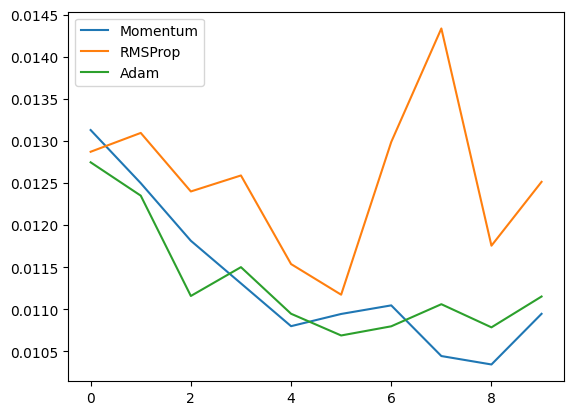

In [26]:
plt.plot(losses["val"], label='Momentum')
plt.plot(losses_RMS["val"], label='RMSProp')
plt.plot(losses_Adam["val"], label='Adam')

plt.legend()
plt.show()

<font color="blue">**Exercise 8**: Calculate the Accuracy for each individual class in the dataset and plot the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html#sklearn.metrics.plot_confusion_matrix) of your trained models.</font>

In [27]:
import pandas as pd

def confMat_Acc(model, val_loader):

  with torch.no_grad():

      accuracies = {}
      confusion_matrix = np.zeros((10,10))
      classes = {'T-shirt/top':0,'Trouser':1, 'Pullover':2, 'Dress':3, 'Coat':4, 'Sandal':5, 'Shirt':6, 'Sneaker':7, 'Bag':8, 'Ankle boot':9}

      for data, target in val_loader:

        data, target = data.to(device), target.to(device)
        data = data.view(-1, 28*28)

        output = model(data)
        predictions = np.argmax(output.cpu().numpy(), axis=1).tolist()
        true = target.cpu().numpy().tolist()

        for i in range(len(predictions)):
          test = val_set.classes[predictions[i]] == val_set.classes[true[i]]
          confusion_matrix[classes[val_set.classes[true[i]]],classes[val_set.classes[predictions[i]]]] += 1

          if val_set.classes[true[i]] in accuracies.keys():
            if test:
              accuracies[val_set.classes[true[i]]][0] = (accuracies[val_set.classes[true[i]]][0] * accuracies[val_set.classes[true[i]]][1] + 1) / (accuracies[val_set.classes[true[i]]][1] + 1)
            else:
              accuracies[val_set.classes[true[i]]][0] = (accuracies[val_set.classes[true[i]]][0] * accuracies[val_set.classes[true[i]]][1]) / (accuracies[val_set.classes[true[i]]][1] + 1)
          else:
            if test:
              accuracies[val_set.classes[true[i]]] = [1,1]
            else:
              accuracies[val_set.classes[true[i]]] = [0,1]

          accuracies[val_set.classes[true[i]]][1] += 1

      confusion_matrix = confusion_matrix.astype('float') / confusion_matrix.sum(axis=1)[:, np.newaxis]
      confusion_matrix = pd.DataFrame(confusion_matrix, index = val_set.classes, columns = val_set.classes)
      accuracies = pd.DataFrame(accuracies)

  return confusion_matrix, accuracies




In [28]:
print("Momentum : ")
conf_matrix, accuracies = confMat_Acc(model, val_loader)
print("  - Confusion matrix : \n", conf_matrix)
print("  - Accuracies       : \n", accuracies.iloc[0])

print("-------------------------------------------------")

print("RMSProp : ")
conf_matrix, accuracies = confMat_Acc(modelRMSProp, val_loader)
print("  - Confusion matrix : \n", conf_matrix)
print("  - Accuracies       : \n", accuracies.iloc[0])

print("-------------------------------------------------")

print("Adam : ")
conf_matrix, accuracies = confMat_Acc(modelAdam, val_loader)
print("  - Confusion matrix : \n", conf_matrix)
print("  - Accuracies       : \n", accuracies.iloc[0])

Momentum : 
  - Confusion matrix : 
              T-shirt/top  Trouser  Pullover  Dress   Coat  Sandal  Shirt  \
T-shirt/top        0.799    0.002     0.020  0.026  0.002   0.000  0.143   
Trouser            0.005    0.962     0.004  0.021  0.003   0.000  0.005   
Pullover           0.015    0.000     0.863  0.011  0.038   0.001  0.068   
Dress              0.017    0.005     0.019  0.895  0.015   0.000  0.044   
Coat               0.001    0.001     0.215  0.039  0.645   0.000  0.097   
Sandal             0.000    0.000     0.000  0.001  0.000   0.934  0.000   
Shirt              0.087    0.001     0.099  0.024  0.029   0.000  0.750   
Sneaker            0.000    0.000     0.000  0.000  0.000   0.011  0.000   
Bag                0.003    0.000     0.001  0.006  0.003   0.003  0.008   
Ankle boot         0.001    0.000     0.000  0.000  0.000   0.012  0.000   

             Sneaker    Bag  Ankle boot  
T-shirt/top    0.000  0.008       0.000  
Trouser        0.000  0.000       0.000  


As we can see here, the use of a special optimizer can really change the final result. We obtain here 3 different models, that are well accurate for certain objects, but less for others. And what is quite interesting is that each model has 1 or 2 objects with a lower accuracy, and those weaknesses are different from one model to another one.